---
downloads:
  - id: notes-9a
    title: PDF notes
  - file: 9a_FTs.ipynb
    title: Notebook
  - file: ../in-class/9a_exercises.ipynb
    title: In-class Exercises
title: Fourier Transforms
---


# Fourier Transforms
In physics, you'll primarily hear of Fourier Transforms (FTs) in physics for two primary use cases:

1. Data Analysis
    - Searching for periodic signatures in data
    - Filtering data in frequency space

2. Computation
    - Converting derivatives into products in frequency space
    - Numerical Error Analysis
    - Spectral methods for solving PDEs

It is the second use case for which we are going to take this interlude in our PDE solving section, but we'll touch on both this week.


## Fourier Series Expansion
The core of FTs lies in the representation of functions as Fourier Series. 

So far, in our analyses of numerical methods, we have relied on the Taylor Series expansion for some function $f(x)$ about $x=a$:

$$f(x) = f(a) + \frac{f'(a)}{1!}(x - a) + \frac{f''(a)}{2!}(x - a)^2 + \frac{f'''(a)}{3!}(x - a)^3 + \dots$$

But we can also typically represent any periodic function $f(x)$ defined between $0$ and $L$ as a **Fourier Series Expansion**:

For even (symmetric) functions with respect to the midpoint:

$$f(x) = \sum_{k=0}^{\infty} \alpha_k \cos\left(\frac{2\pi k x}{L}\right)$$

For odd (anti-symmetric) functions with respect to the midpoint:

$$f(x) = \sum_{k=1}^{\infty} \beta_k \sin\left(\frac{2\pi k x}{L}\right)$$

Or, in general, as a sum of even and odd parts, in terms of a complex series.

Recall: $e^{ix} = \cos{x} + i\sin{x}$

$$f(x) = \sum_{k=-\infty}^{\infty} \gamma_k \exp\left( i \frac{2\pi k x}{L} \right)$$

where, the coefficents $\gamma_k$ are given by the integral:

$$\gamma_k = \frac{1}{L}\int_{0}^{L} f(x) \exp\left(-i\frac{2\pi k x}{L}\right) dx$$

While Fourier series are technically only for periodic functions, we can typically cheat by replicating it's shape over a range of interest to obtain the series decomposition.

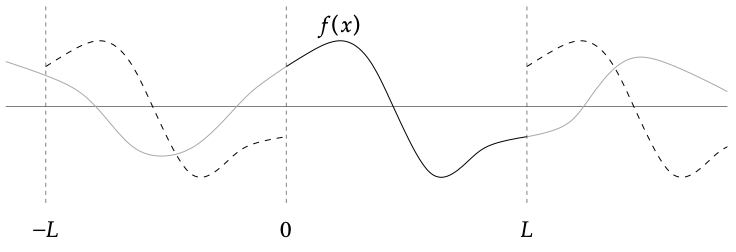

### Applications
A Fourier Transform decomposes a function into a series of waves at different frequencies. The coefficients tell us the relative contribution of each frequency to the overall signal, also called a Power Spectrum. 

Power spectra crop up all over physics, such as:
+ Energy cascade of [turbulence](https://en.wikipedia.org/wiki/Energy_cascade)
+ [Structure function of matter](https://en.wikipedia.org/wiki/Matter_power_spectrum) in the Universe
+ [Anisotropies in the Cosmic Microwave Background](https://en.wikipedia.org/wiki/Matter_power_spectrum)
+ [Interferometric imaging](http://science.nrao.edu/facilities/alma/naasc-workshops/nrao-cd-jhu18/Interferometry_Basics.pdf)

and Fourier methods are used heavily in many areas of signal and image processing, with applications across engineering. 

You use technologies that rely on FTs every day:
+ [JPEG image format](https://en.wikipedia.org/wiki/JPEG#JPEG_compression) stores images as the 2D Fourier transform coefficients (neglecting smaller coefficients to compress the file size). 
+ MPEG does the same for movies.
+ MP3 uses the same principle for audio files, discarding coefficients for frequencies outside human perception. 


### Discrete Fourier Transforms (DFTs)
As defined above, if we want to figure out the coefficients of a power spectrum, we'll need to take an integral. In numerics, we don't often have a continuous function, but a set of discrete data points. In this case, we can perform a **Discrete Fourier Transform** by representing it as a numerical integral (for example, using the Trapezoidal Rule from week 4):

$$\gamma_k = \frac{1}{L}\int_{0}^{L} f(x) \exp\left(-i\frac{2\pi k x}{L}\right) dx = \gamma_k = \frac{1}{N} \sum_{n=0}^{N-1} f(x_n) \exp\left(-i \frac{2\pi k x_n}{L}\right)$$

in the case where the function is defined between $x = 0$ and $x=L$, we assume that $f(L) = f(0)$ and we have evenly spaced sample points, such that the nth point is: $x_n = n L/N$

The formal definition of a DFT is given by the coefficients $c_k$:
$$c_k = N \gamma_k = \sum_{n=0}^{N-1} f(x_n) \exp\left(-i \frac{2 \pi k x_n}{L}\right)$$

### Ex: DFT Signal
Let's look at a signal from a file in [pitch.txt](../in-class/pitch.txt). (You'll be using this in your in-class exercise later.)

Text(0, 0.5, 'signal')

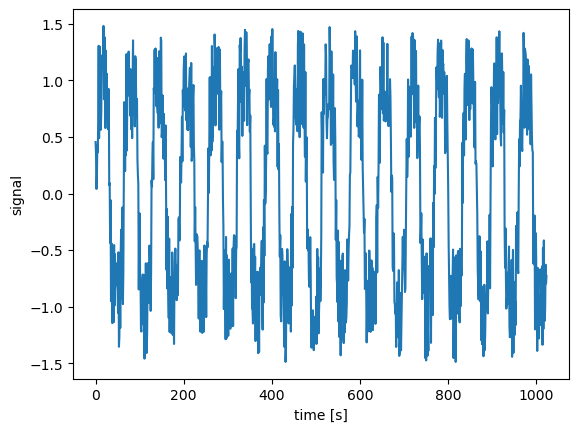

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

signal = np.loadtxt("../in-class/pitch.txt",float)

fig,ax = plt.subplots()
ax.plot(signal)
ax.set_xlabel("time [s]")
ax.set_ylabel("signal")

An implementation for a DFT for calculating $c_k$ for all $k$ between $0$ and $N-1$ looks like. Here, we'll plot the absolute value of the coefficients as a function of $k$.

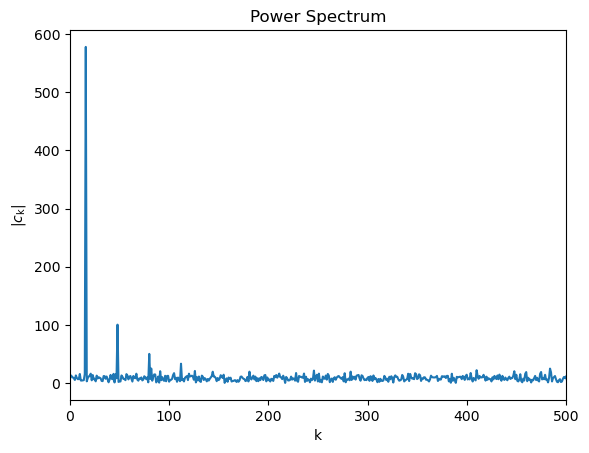

In [ ]:
def dft(f):
    """ Calculates the DFT of a set of data points of f, assuming evenly spaced from 0 to L, where L = N. For k between 0 and N-1."""
    N = len(f)    
    c = np.zeros(N,complex) 
    for k in range(N): 
        for n in range(N):
            c[k] += f[n]*np.exp(-2j*np.pi*k*n/N)
    return c

c = dft(signal)

fig, ax = plt.subplots()
ax.plot(np.abs(c))
ax.set_xlabel("k")
ax.set_ylabel(r"$|c_{\rm k}|$")
ax.set_xlim(0,500)
ax.set_title("Power Spectrum")
plt.show()

So, what are we seeing in the plot?
+ The highest amplitude peak is telling us about the main frequency.
+ Peaks that are multiples of the main frequency are typically known as **harmonics**.
+ The baseline level (notice the spectrum is never quite zero), on average the same amount across all frequencies, is known as **white noise**: these are randome fluctuations in the data 

But how do we check the result?

### Calculating the Inverse DFT

$$y_n = \frac{1}{N} \sum_{k=0}^{N-1} c_k \exp\left(i \frac{2 \pi k x_n}{L}\right)$$

We should be able to recover the original function by computing the *inverse* DFT using the Fourier coefficients. 

<h2><span class="fa fa-flash"></span> In-Class Coding Exercise </h2>

```{embed} icc_9-1
```

:question:

```{embed} ex_9-1
```


### Real-valued vs. Complex-valued Functions
If our function is real-valued, then the value of the coefficient for $k = N - r$ is equal to the complex conjugate of the coefficient at $k=r$. 

In practice, this means that for real-valued functions, we only need to calculate coefficients between $0$ and $N/2$, and then just concatenate them with the complex conjugate of the same array in reverse.

For complex functions, you would still need to calculate for all N.

<h2><span class="fa fa-flash"></span> In-Class Coding Exercise </h2>

```{embed} icc_9-2
```


### Further Applications: 2D Fourier Transforms
We can extend the methods above for functions $f(x,y)$ of two variables. 

Suppose we have a function $f_{mn}$ sampled on an $M \times N$ grid. 

We'd first perform a DFT on each of the $M$ rows to get $N$ coefficients for each row:

$$c'_{ml} = \sum_{n=0}^{N-1} f_{mn} \exp\left(-i \frac{2\pi l x_n }{L}\right)$$

Then, we'd take the $lth$ coefficent in each of the $M$ rows and FT the values again. 

All together, we can write the two operations as a nested set of sums to get the coefficients in $k-l$ space. 
$$ c_{kl} = \sum_{m=0}^{M-1} \sum_{n=0}^{N-1} f_{mn} \exp\left[-i 2\pi \left( \frac{k y_m}{L} + \frac{l x_n}{L} \right)\right] $$


## Scaling of FT methods
:question:

```{embed} ex_9-2
```

```{embed} sol_9-2
```

This scaling is not great!

For context, $N=45000$ sample points is about 1 second of music at today's sampling. 

Luckily, Gauss solved this problem for us in 1805 with the *Fast Fourier Transform* (FFT).

### Fast Fourier Transform (FFT)
Instead of calculating the FT for $N$ coefficients over $N$ points, we recursively calculate $N/2$ FTs for every pair of points. 

This works because we can express the coefficient as the sum of two FTs with $N/2$ data points, with a *twiddle* factor: $e^{-i2\pi k / N}$

$$c_k = E_k + e^{-i2\pi k / N} O_k$$

The sum of even terms is:
$$E_k = \sum_{r=0}^{\frac{1}{2}N-1} y_{2r} \exp\left(-i \frac{2\pi k (2r)}{N}\right) = \sum_{r=0}^{\frac{1}{2}N-1} y_{2r} \exp\left(-i \frac{2\pi k r}{\frac{1}{2}N}\right)$$

And the sum of the odd terms is:
$$\sum_{r=0}^{\frac{1}{2}N-1} y_{2r+1} \exp\left(-i \frac{2\pi k (2r+1)}{N}\right) = e^{-i 2\pi k / N} \sum_{r=0}^{\frac{1}{2}N-1} y_{2r+1} \exp\left(-i \frac{2\pi k r}{\frac{1}{2}N}\right) = e^{-i 2\pi k / N} O_k$$

But recursively, each FT can be expressed as its own sum of half as many points.

Thus, starting with each point, the FT of the point is just itself, we work our way up, thus requiring only $N\log (N)$ calculations. See Newman 7.4.1 for explicit formulas.

<h2><span class="fa fa-flash"></span> In-Class Coding Exercise </h2>

```{embed} icc_9-3
```

## FTs for PDEs
Let's re-consider the Poisson Equation from last week:
$$\frac{d^{2}\phi}{dx^{2}} = f(x)$$

If we have **periodic BCs**, we can write the functions in terms of Fourier Series:
$$ \phi(x) = \int \Phi(k)e^{-2\pi i k x} \, dk \\

f(x) = \int F(k)e^{-2\pi i k x} \, dk$$

In Fourier space, [derivatives](https://en.wikipedia.org/wiki/Fourier_transform#Differentiation) are fairly straightforward:
$$\frac{d\phi}{dx} \rightarrow 2\pi i k \Phi(k)$$
and:
$$\frac{d^{2}\phi}{dx^{2}} \rightarrow -4\pi^2 k^2 \Phi(k)$$

Thus, the PDE becomes an algebraic equation in Fourier Space:
$$-4\pi^2 k^2 \Phi(k) = F(k)$$

Which we solve for $\Phi(k)$ and transform back to solve for $\phi(x)$.

```{note} Ex: Solving Gravity
:class: dropdown
Calculating gravitational potential by hand for an arbitrary mass distribution on a grid is a doozy. (This comes up quite a lot in astrophysics problems where self-gravity is important)

The potential at a single point $x$ is computed as the following integral over all points:
$$\phi(x) = - \int_{\mathbb{R}^3} \frac{G}{\|x - r\|} \rho(r) dV(r)$$

Which you then have to compute at every single point. In practice, this is prohibitively computationally expensive, so most big astrophysical fluids codes depend on using FFTs to solve Poisson's Equation for gravity instead:
$$\nabla^2 \phi = 4\pi G \rho$$
```

This method is quite powerful, especially when extended to multiple dimensions. The main catch is the required specificity of the behavior of your function on the boundaries. This constraint returns again when we will discuss Spectral Methods for PDEs next week. 